# Exploratory Data Analysis: Mufulira Budget Raw Tables (2023–2026)

## 1. Introduction

This notebook performs Exploratory Data Analysis (EDA), data quality assessment, and preprocessing of the raw budget-table dataset extracted from Mufulira Municipal Council budget documents for 2023, 2024, 2025, and 2026.

The raw dataset contains tables extracted from the four official budget PDF documents before the records were transformed into the structured budget and revenue dataset.

The objectives of this analysis are to:

- understand the structure of the raw extracted tables;
- assess completeness and consistency;
- identify duplicate, malformed, or irrelevant records;
- identify extraction artefacts arising from PDF table parsing;
- apply appropriate cleaning and preprocessing; and
- document the decisions made during the cleaning process.

The dataset is pipe-delimited (`|`) as required by the project.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = (
    "scrapping/budget_scraper/"
    "db-unza26-csc4792_mufulira_budget_raw_tables_2023_2026.csv"
)

df = pd.read_csv(file_path, sep="|", low_memory=False)

df.head()

,year,page,table_number,row_number,source_title,source_url,table_column_1,table_column_2,table_column_3,table_column_4,table_column_5,table_column_6,table_column_7,table_column_8
0,2023,2,1,1,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,NaN,NaN,REVISED BUDGET 2023,NaN,BUDGET ESTIMATE 2024
1,2023,2,1,2,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,01,Local taxes/rates,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,2,1,3,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,001,Residential,"7,730,999",NaN,NaN,"8,364,941",NaN,"8,975,582 8,671,504 32,695,660"
3,2023,2,1,4,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,002,Industrial/Commercial,"7,469,086",NaN,NaN,"8,081,551",NaN,NaN
4,2023,2,1,5,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,003,Mining/Plant,"28,161,976",NaN,NaN,"30,471,258",NaN,NaN


## 2. Initial Dataset Inspection

The first stage of the EDA establishes the size, structure, column names, data types, and initial contents of the raw extracted dataset.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 10 records:")
display(df.head(10))

Number of rows: 1638
Number of columns: 14

Column names:
['year', 'page', 'table_number', 'row_number', 'source_title', 'source_url', 'table_column_1', 'table_column_2', 'table_column_3', 'table_column_4', 'table_column_5', 'table_column_6', 'table_column_7', 'table_column_8']

Data types:
year              int64
page              int64
table_number      int64
row_number        int64
source_title        str
source_url          str
table_column_1      str
table_column_2      str
table_column_3      str
table_column_4      str
table_column_5      str
table_column_6      str
table_column_7      str
table_column_8      str
dtype: object

First 10 records:


,year,page,table_number,row_number,source_title,source_url,table_column_1,table_column_2,table_column_3,table_column_4,table_column_5,table_column_6,table_column_7,table_column_8
0,2023,2,1,1,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,NaN,NaN,REVISED BUDGET 2023,NaN,BUDGET ESTIMATE 2024
1,2023,2,1,2,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,01,Local taxes/rates,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,2,1,3,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,001,Residential,"7,730,999",NaN,NaN,"8,364,941",NaN,"8,975,582 8,671,504 32,695,660"
3,2023,2,1,4,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,002,Industrial/Commercial,"7,469,086",NaN,NaN,"8,081,551",NaN,NaN
4,2023,2,1,5,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,003,Mining/Plant,"28,161,976",NaN,NaN,"30,471,258",NaN,NaN
5,2023,2,1,6,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,NaN,SubItem Total,NaN,"43,362,061",NaN,"46,917,750",NaN,"50,342,746"
6,2023,2,1,7,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,001,Personal levy,"190,005",NaN,NaN,"205,585",NaN,"220,593"
7,2023,2,1,8,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,NaN,SubItem Total,NaN,"190,005",NaN,"205,585",NaN,"220,593"
8,2023,2,1,9,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,NaN,NaN,REVISED BUDGET 2023,NaN,BUDGET ESTIMATE 2024
9,2023,2,1,10,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,02,Fees and Charges,NaN,NaN,NaN,NaN,NaN,NaN


### 2.1 Raw Table Structure

Because the dataset was produced by extracting tables directly from budget PDFs, the records are examined for structural artefacts such as repeated headers, blank rows, partially populated rows, and records originating from different table structures.

In [3]:
print("Rows with all values missing:")
print(df.isna().all(axis=1).sum())

print("\nRows with at least one missing value:")
print(df.isna().any(axis=1).sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Rows with all values missing:
0

Rows with at least one missing value:
1638

Duplicate rows:
0


## 3. Budget-Year Coverage

The raw tables were extracted from four Mufulira Municipal Council budget documents covering 2023–2026.

The year distribution is examined to determine whether records from all four source documents are represented.

In [4]:
print(df.columns.tolist())

['year', 'page', 'table_number', 'row_number', 'source_title', 'source_url', 'table_column_1', 'table_column_2', 'table_column_3', 'table_column_4', 'table_column_5', 'table_column_6', 'table_column_7', 'table_column_8']


In [5]:
year_col = next(
    (
        col for col in df.columns
        if "year" in str(col).lower()
    ),
    None
)

print("Detected year column:", year_col)

if year_col:
    print("\nRecords by year:")
    display(df[year_col].value_counts(dropna=False).sort_index())
else:
    print("No year column was detected.")

Detected year column: year

Records by year:


year
2023    274
2024    379
2025    542
2026    443
Name: count, dtype: int64

## 4. Raw Field Completeness

The raw table dataset may contain many text fields because PDF table extraction preserves the original table cells.

The completeness of each column is examined to identify fields that are predominantly empty and therefore may represent table-specific rather than dataset-wide attributes.

In [6]:
completeness = pd.DataFrame({
    "Non_Missing": df.notna().sum(),
    "Missing": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2)
})

display(completeness)

,Non_Missing,Missing,Missing_Percentage
year,1638,0,0.00
page,1638,0,0.00
table_number,1638,0,0.00
row_number,1638,0,0.00
source_title,1638,0,0.00
source_url,1638,0,0.00
table_column_1,998,640,39.07
table_column_2,1153,485,29.61
table_column_3,1070,568,34.68
table_column_4,727,911,55.62


## 5. Repeated Header and Extraction Artefact Detection

PDF table extraction can preserve header rows as if they were ordinary data records.

The raw dataset is therefore searched for records containing common budget-table header terms.

In [7]:
header_terms = [
    "code",
    "description",
    "approved budget",
    "revised budget",
    "budget estimate",
    "revenue description"
]

for term in header_terms:
    mask = df.astype("string").apply(
        lambda column: column.str.contains(
            term,
            case=False,
            na=False,
            regex=False
        )
    ).any(axis=1)

    print(f'"{term}" appears in {mask.sum()} rows')

"code" appears in 39 rows
"description" appears in 35 rows
"approved budget" appears in 1638 rows
"revised budget" appears in 35 rows
"budget estimate" appears in 43 rows
"revenue description" appears in 35 rows


In [8]:
header_mask = df.astype("string").apply(
    lambda column: column.str.contains(
        "code|description|approved budget|revised budget|budget estimate",
        case=False,
        na=False,
        regex=True
    )
).any(axis=1)

print("Potential header/artefact rows:", header_mask.sum())

display(df[header_mask].head(20))

Potential header/artefact rows: 1638


,year,page,table_number,row_number,source_title,source_url,table_column_1,table_column_2,table_column_3,table_column_4,table_column_5,table_column_6,table_column_7,table_column_8
0,2023,2,1,1,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,NaN,NaN,REVISED BUDGET 2023,NaN,BUDGET ESTIMATE 2024
1,2023,2,1,2,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,01,Local taxes/rates,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,2,1,3,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,001,Residential,"7,730,999",NaN,NaN,"8,364,941",NaN,"8,975,582 8,671,504 32,695,660"
3,2023,2,1,4,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,002,Industrial/Commercial,"7,469,086",NaN,NaN,"8,081,551",NaN,NaN
4,2023,2,1,5,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,003,Mining/Plant,"28,161,976",NaN,NaN,"30,471,258",NaN,NaN
5,2023,2,1,6,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,NaN,SubItem Total,NaN,"43,362,061",NaN,"46,917,750",NaN,"50,342,746"
6,2023,2,1,7,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,001,Personal levy,"190,005",NaN,NaN,"205,585",NaN,"220,593"
7,2023,2,1,8,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,NaN,SubItem Total,NaN,"190,005",NaN,"205,585",NaN,"220,593"
8,2023,2,1,9,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,NaN,NaN,REVISED BUDGET 2023,NaN,BUDGET ESTIMATE 2024
9,2023,2,1,10,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,02,Fees and Charges,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Empty-Row Analysis

Completely empty rows provide no analytical information and may result from blank rows or page/table separation during PDF extraction.

In [9]:
empty_rows = df.isna().all(axis=1)

print("Completely empty rows:", empty_rows.sum())

Completely empty rows: 0


## 7. Cleaning and Preprocessing

The raw dataframe is preserved unchanged as `df`.

A separate dataframe, `df_cleaned`, is created for preprocessing. This allows the original extraction output to remain available for comparison and auditability.

Because this is a raw table dataset, cleaning focuses on extraction artefacts rather than aggressively transforming the underlying information.

In [10]:
df_cleaned = df.copy()

# Remove rows that are completely empty.
df_cleaned = df_cleaned.dropna(how="all").copy()

print("Original rows:", len(df))
print("Rows after removing completely empty records:", len(df_cleaned))

Original rows: 1638
Rows after removing completely empty records: 1638


### 7.1 Text Standardization

Leading and trailing whitespace is removed from textual fields.

No substantive text is rewritten at this stage because the raw dataset is intended to preserve the information extracted from the source budget tables.

In [11]:
text_columns = df_cleaned.select_dtypes(
    include=["object", "string"]
).columns

for column in text_columns:
    df_cleaned[column] = (
        df_cleaned[column]
        .astype("string")
        .str.strip()
    )

print("Text whitespace standardized.")

Text whitespace standardized.


### 7.2 Handling Repeated Table Headers

Rows identified as repeated budget-table headers are treated as extraction artefacts only when their content clearly represents column headings rather than an actual budget record.

This prevents genuine budget records containing similar terminology from being removed incorrectly.

In [12]:
header_pattern = (
    r"^\s*code\s*$|"
    r"^\s*revenue description\s*$|"
    r"approved budget|"
    r"revised budget|"
    r"budget estimate"
)

header_like = df_cleaned.astype("string").apply(
    lambda column: column.str.contains(
        header_pattern,
        case=False,
        na=False,
        regex=True
    )
).any(axis=1)

print("Potential header-like rows:", header_like.sum())

display(df_cleaned[header_like].head(20))

Potential header-like rows: 1638


,year,page,table_number,row_number,source_title,source_url,table_column_1,table_column_2,table_column_3,table_column_4,table_column_5,table_column_6,table_column_7,table_column_8
0,2023,2,1,1,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,<NA>,<NA>,REVISED BUDGET 2023,<NA>,BUDGET ESTIMATE 2024
1,2023,2,1,2,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,01,Local taxes/rates,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2023,2,1,3,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,001,Residential,"7,730,999",<NA>,<NA>,"8,364,941",<NA>,"8,975,582 8,671,504 32,695,660"
3,2023,2,1,4,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,002,Industrial/Commercial,"7,469,086",<NA>,<NA>,"8,081,551",<NA>,<NA>
4,2023,2,1,5,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,003,Mining/Plant,"28,161,976",<NA>,<NA>,"30,471,258",<NA>,<NA>
5,2023,2,1,6,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,<NA>,SubItem Total,<NA>,"43,362,061",<NA>,"46,917,750",<NA>,"50,342,746"
6,2023,2,1,7,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,001,Personal levy,"190,005",<NA>,<NA>,"205,585",<NA>,"220,593"
7,2023,2,1,8,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,<NA>,SubItem Total,<NA>,"190,005",<NA>,"205,585",<NA>,"220,593"
8,2023,2,1,9,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,<NA>,<NA>,REVISED BUDGET 2023,<NA>,BUDGET ESTIMATE 2024
9,2023,2,1,10,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,02,Fees and Charges,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [14]:
table_columns = [col for col in df_cleaned.columns if str(col).startswith("table_column_")]

header_pattern = (
    r"^\s*code\s*$|"
    r"^\s*revenue description\s*$|"
    r"^\s*approved budget.*$|"
    r"^\s*revised budget.*$|"
    r"^\s*budget estimate.*$"
)

header_like = df_cleaned[table_columns].astype("string").apply(
    lambda column: column.str.contains(
        header_pattern,
        case=False,
        na=False,
        regex=True
    )
).any(axis=1)

print("Potential header-like rows:", header_like.sum())
display(df_cleaned.loc[header_like].head(20))

Potential header-like rows: 39


,year,page,table_number,row_number,source_title,source_url,table_column_1,table_column_2,table_column_3,table_column_4,table_column_5,table_column_6,table_column_7,table_column_8
0,2023,2,1,1,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,<NA>,<NA>,REVISED BUDGET 2023,<NA>,BUDGET ESTIMATE 2024
8,2023,2,1,9,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,<NA>,<NA>,REVISED BUDGET 2023,<NA>,BUDGET ESTIMATE 2024
39,2023,3,2,1,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,<NA>,<NA>,REVISED BUDGET 2023,<NA>,BUDGET ESTIMATE 2024
47,2023,3,2,9,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,<NA>,<NA>,REVISED BUDGET 2023,<NA>,BUDGET ESTIMATE 2024
52,2023,3,2,14,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,<NA>,<NA>,REVISED BUDGET 2023,<NA>,BUDGET ESTIMATE 2024
60,2023,3,2,22,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,<NA>,<NA>,REVISED BUDGET 2023,<NA>,BUDGET ESTIMATE 2024
66,2023,3,2,28,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,<NA>,<NA>,REVISED BUDGET 2023,<NA>,BUDGET ESTIMATE 2024
70,2023,3,2,32,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2022,<NA>,<NA>,REVISED BUDGET 2023,<NA>,BUDGET ESTIMATE 2024
75,2023,4,4,1,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Code,Programme,2021 Approved Budget(K),2022 Approved Budget(K),2023 Budget(K) Estimates,<NA>,<NA>,<NA>
274,2024,3,1,1,Approved Budget 2024,https://www.mufuliracouncil.gov.zm/wp-content/...,CODE,REVENUE DESCRIPTION,APPROVED BUDGET 2024,<NA>,<NA>,REVISED BUDGET 2025,<NA>,BUDGET ESTIMATE 2026


In [15]:
df_cleaned = df_cleaned.loc[~header_like].copy()

print("Rows after removing repeated header rows:", len(df_cleaned))

Rows after removing repeated header rows: 1599


In [16]:
duplicate_count = df_cleaned.duplicated().sum()

print("Duplicate rows after header removal:", duplicate_count)

Duplicate rows after header removal: 0


In [17]:
print("Data types after cleaning:")
print(df_cleaned.dtypes)

Data types after cleaning:
year               int64
page               int64
table_number       int64
row_number         int64
source_title      string
source_url        string
table_column_1    string
table_column_2    string
table_column_3    string
table_column_4    string
table_column_5    string
table_column_6    string
table_column_7    string
table_column_8    string
dtype: object


## 8. Numeric and Budget-Value Inspection

The raw budget dataset contains extracted financial values across the table columns. Because the source documents were processed from PDF tables, some values may contain commas, missing values, or multiple numbers concatenated into a single cell.

Before converting these fields to numeric values, their contents are inspected to distinguish valid monetary values from extraction artefacts.

In [18]:
numeric_candidates = [
    "table_column_3",
    "table_column_4",
    "table_column_5",
    "table_column_6",
    "table_column_7",
    "table_column_8"
]

for column in numeric_candidates:
    if column in df_cleaned.columns:
        print(f"\n{column}")
        print(df_cleaned[column].dropna().head(10).to_list())


table_column_3
['7,730,999', '7,469,086', '28,161,976', '190,005', '49,000', '29,700', '423,500', '551,500', '16,550', '586,990']

table_column_4
['43,362,061', '190,005', '10,350,231', '911,900', '1,111,800', '2,021,290', '2,831,000', '11,519,010', '84,900,000', '182,387,287']

table_column_5
['84,900,000 1,934,160 1,086,695 3,543,415 13,298,171 2,131,611 233,620 1,683,722 44,568,645 3,817,257', '157,197,296', '2023 BUDGET ESTIMATE (K)', '41,537,887 105,204,414 - 10,454,994', '157,197,296', 'EXPENDITURE*', '-', '-', '-', '-']

table_column_6
['8,364,941', '8,081,551', '30,471,258', '46,917,750', '205,585', '205,585', '53,018', '32,135', '458,227', '596,723']

table_column_7
['1,633,021 2,131,611 533,050 1,598,561 233,620 68,660 164,960 1,683,722 343,400 182,360 1,157,962 44,568,645 30,721,773 2,266,568 645,657 387,061 7,259,115 2,534,711 300,000 453,761 3,817,257 1,411,624 1,425,283 980,350', '157,197,296', 'Expenditure*', '- -', '-', 'Expenditure*', '- - -', '-', '-', 'Expenditure*'

## 9. Numerical Cleaning of Budget Fields

The raw budget tables contain financial values represented as text, often with comma separators. Some cells also contain multiple concatenated values because of PDF table extraction.

For reliable analysis, values that can be interpreted as individual monetary amounts are converted to numeric form. Cells containing multiple concatenated values are retained as raw text rather than being assigned an incorrect numeric value.

In [19]:
import re

budget_columns = [
    "table_column_3",
    "table_column_4",
    "table_column_5",
    "table_column_6",
    "table_column_7",
    "table_column_8"
]

for column in budget_columns:
    if column in df_cleaned.columns:
        df_cleaned[column + "_numeric"] = (
            df_cleaned[column]
            .astype("string")
            .str.replace(",", "", regex=False)
            .where(
                lambda s: s.str.fullmatch(r"\d+(?:\.\d+)?", na=False)
            )
            .astype("Float64")
        )

print("Numeric budget columns created.")
display(df_cleaned.head())

Numeric budget columns created.


,year,page,table_number,row_number,source_title,source_url,table_column_1,table_column_2,table_column_3,table_column_4,table_column_5,table_column_6,table_column_7,table_column_8,table_column_3_numeric,table_column_4_numeric,table_column_5_numeric,table_column_6_numeric,table_column_7_numeric,table_column_8_numeric
1,2023,2,1,2,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,01,Local taxes/rates,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2023,2,1,3,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,001,Residential,"7,730,999",<NA>,<NA>,"8,364,941",<NA>,"8,975,582 8,671,504 32,695,660",7730999.0,<NA>,<NA>,8364941.0,<NA>,<NA>
3,2023,2,1,4,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,002,Industrial/Commercial,"7,469,086",<NA>,<NA>,"8,081,551",<NA>,<NA>,7469086.0,<NA>,<NA>,8081551.0,<NA>,<NA>
4,2023,2,1,5,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,003,Mining/Plant,"28,161,976",<NA>,<NA>,"30,471,258",<NA>,<NA>,28161976.0,<NA>,<NA>,30471258.0,<NA>,<NA>
5,2023,2,1,6,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,<NA>,SubItem Total,<NA>,"43,362,061",<NA>,"46,917,750",<NA>,"50,342,746",<NA>,43362061.0,<NA>,46917750.0,<NA>,50342746.0


## 10. Verification of Numeric Budget Fields

The newly created numeric columns are inspected to confirm that valid individual monetary values were converted successfully while ambiguous concatenated values were left as missing.

In [20]:
numeric_columns = [
    column for column in df_cleaned.columns
    if column.endswith("_numeric")
]

display(df_cleaned[numeric_columns].describe())

,table_column_3_numeric,table_column_4_numeric,table_column_5_numeric,table_column_6_numeric,table_column_7_numeric,table_column_8_numeric
count,254.0,189.0,209.0,527.0,85.0,204.0
mean,8737259.149606,15251544.322751,14850414.84689,4494728.952562,2967019434911098.5,6532281.352941
std,33529898.097249,46789955.320516,45293554.661887,16707652.391706,16953548710159560.0,19122441.155602
min,216.0,1.0,0.0,0.0,141800.0,238.0
25%,46175.0,300.0,8.0,100.0,3402364.0,52331.0
50%,195002.5,2024.0,346886.0,24840.0,165160565065.0,238933.5
75%,900000.0,923951.0,2814902.0,566157.0,33575373535131.0,1268558.5
max,242956526.0,247056165.0,222323765.0,132000000.0,112200009977665504.0,120097650.0


## 11. Distribution of Records by Year

The raw budget dataset covers multiple budget years from 2023 to 2026. The number of extracted records for each year is examined to assess the distribution of the dataset across the four source documents.

Records by year:


year
2023    265
2024    369
2025    532
2026    433
Name: count, dtype: int64

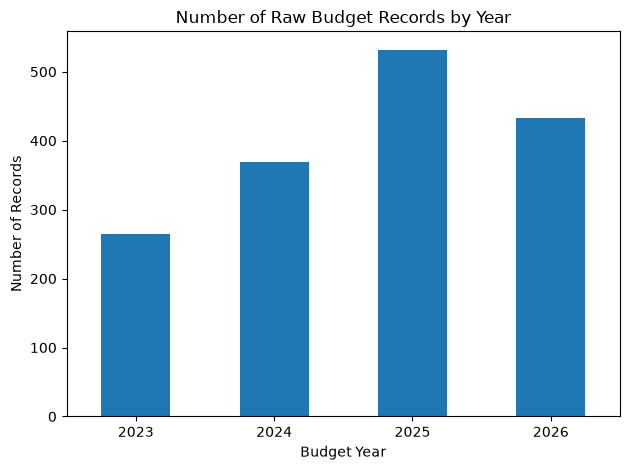

In [21]:
year_counts = df_cleaned["year"].value_counts().sort_index()

print("Records by year:")
display(year_counts)

year_counts.plot(kind="bar")
plt.title("Number of Raw Budget Records by Year")
plt.xlabel("Budget Year")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. Distribution by Source Document

The dataset was extracted from official Mufulira Municipal Council budget documents. Examining records by source document helps determine how much raw table data was obtained from each budget year/document.

Records by source document:


source_title
Approved Budget 2025    532
Approved Budget 2026    433
Approved Budget 2024    369
Approved Budget 2023    265
Name: count, dtype: Int64

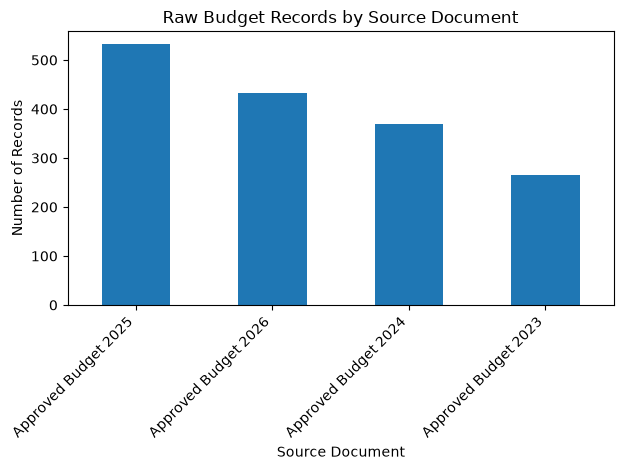

In [22]:
source_counts = df_cleaned["source_title"].value_counts()

print("Records by source document:")
display(source_counts)

source_counts.plot(kind="bar")
plt.title("Raw Budget Records by Source Document")
plt.xlabel("Source Document")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 13. Distribution by Table Number

The raw extraction preserves the table number from each source PDF. Examining the distribution of records across tables helps identify which tables contributed the most data to the final raw dataset.

In [23]:
table_counts = df_cleaned["table_number"].value_counts().sort_index()

print("Records by table number:")
display(table_counts.head(20))

Records by table number:


table_number
1     128
2      99
3      13
4       8
5      22
6      49
7      35
8      18
9      56
10     42
11     19
12     13
13     34
14     29
15     26
16     19
17     33
18     22
19     29
20     17
Name: count, dtype: int64

## 14. Key Findings

The exploratory analysis shows that the raw budget dataset contains extracted records from Mufulira Municipal Council budget documents covering 2023 to 2026.

Several data-quality characteristics were identified:

- The raw tables contain repeated header rows because each table heading was retained during PDF extraction.
- Some fields contain missing values because the original PDF tables use multiple columns and not every record has a value in every column.
- No duplicate records remained after the repeated header rows were removed.
- Some monetary values were extracted correctly as individual values, while others were concatenated within a single cell because of PDF table-layout limitations.
- The dataset preserves source metadata such as budget year, page number, table number, row number, source title, and source URL, which supports traceability to the original documents.

These characteristics show that the dataset is suitable as a documented raw extraction layer, but financial analysis should preferably use the structured budget/revenue dataset rather than treating every raw table column as a clean numeric variable.

## 15. Data Cleaning and Preprocessing Summary

The following preprocessing steps were applied to the raw budget-table dataset:

1. Completely empty records were removed.
2. Leading and trailing whitespace was removed from text fields.
3. Repeated table-header rows were identified using the table-content columns and removed.
4. Duplicate records were checked after header removal; no duplicate rows remained.
5. Numeric-looking budget values were converted into additional numeric fields where the values represented a single valid monetary amount.
6. Ambiguous cells containing concatenated monetary values were not forced into numeric values, preventing incorrect financial interpretation.
7. The original raw fields were retained so that the extracted information remains traceable to the source tables.

## 16. Conclusion

The Mufulira Municipal Council Budget Raw Tables dataset provides a detailed record of information extracted from official budget documents for 2023–2026.

The EDA identified important extraction artefacts associated with PDF table processing, particularly repeated headers, missing table cells, and concatenated financial values. These issues were documented and addressed conservatively without fabricating or incorrectly assigning financial values.

The cleaned dataset therefore serves as a reliable raw extraction layer for the project. For higher-level financial analysis and comparisons, the structured budget/revenue dataset provides a more appropriate representation of the extracted budget information.

In [24]:
print("Original rows:", len(df))
print("Cleaned rows:", len(df_cleaned))
print("Duplicate rows:", df_cleaned.duplicated().sum())
print("Columns:", len(df_cleaned.columns))

Original rows: 1638
Cleaned rows: 1599
Duplicate rows: 0
Columns: 20
